In [1]:
!pip install pandas pandas_datareader fredapi

In [7]:
import pandas as pd
import numpy as np

In [9]:
from fredapi import Fred
fred = Fred(api_key='your_api_key_here')

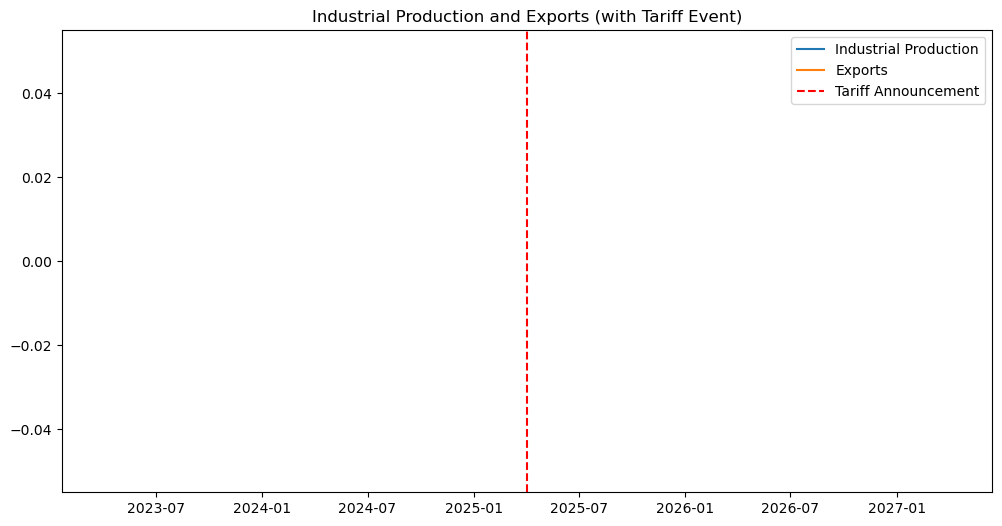

In [11]:
import pandas_datareader.data as web
import datetime

# Set time period
start = datetime.datetime(2025, 4, 1)
end = datetime.datetime(2025, 4, 5)

# Download data
indpro = web.DataReader('INDPRO', 'fred', start, end)  # Industrial Production
exports = web.DataReader('EXPGS', 'fred', start, end)  # Exports

# Plot it
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(indpro, label='Industrial Production')
plt.plot(exports, label='Exports')
plt.axvline(pd.Timestamp('2025-04-03'), color='red', linestyle='--', label='Tariff Announcement')
plt.title('Industrial Production and Exports (with Tariff Event)')
plt.legend()
plt.show()


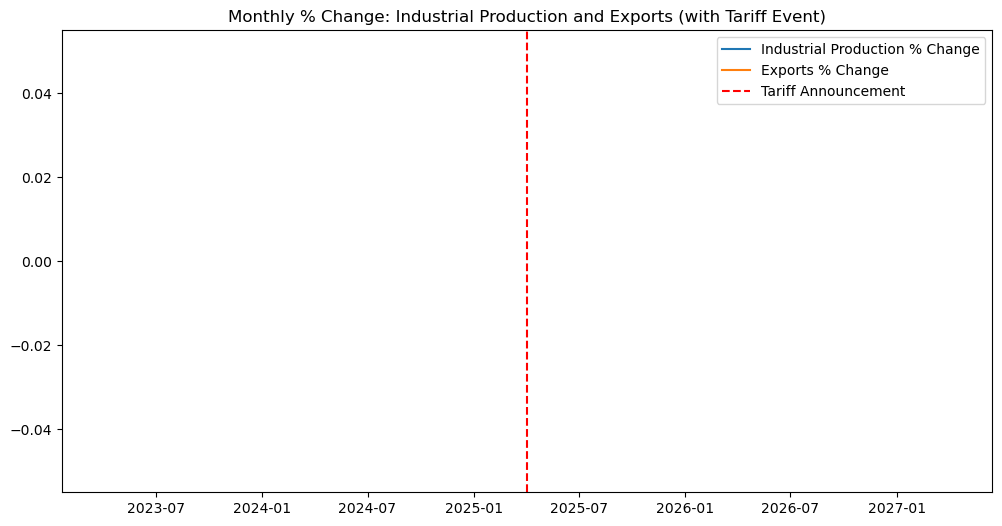

In [13]:
# Convert to monthly percentage changes
indpro_chg = indpro.pct_change()
exports_chg = exports.pct_change()

plt.figure(figsize=(12,6))
plt.plot(indpro_chg, label='Industrial Production % Change')
plt.plot(exports_chg, label='Exports % Change')
plt.axvline(pd.Timestamp('2025-04-03'), color='red', linestyle='--', label='Tariff Announcement')
plt.title('Monthly % Change: Industrial Production and Exports (with Tariff Event)')
plt.legend()
plt.show()
